In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = "https://raw.githubusercontent.com/JasonFreeberg/PythonTutorials/master/AirQualityUCI.csv"

df = pd.read_csv(
    url,
    sep=";",
    decimal=",",
    encoding="latin1"
)

# Remove completely empty rows and columns
df = df.dropna(axis=1, how="all")
df = df.dropna(axis=0, how="all")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:

# Examine the time-related columns

print("First 10 dates:")
print(df["Date"].head(10))

print("\nFirst 10 time values:")
print(df["Time"].head(10))

print("\nNumber of unique dates:", df["Date"].nunique())
print("Number of unique times:", df["Time"].nunique())

print("\nEarliest date in the dataset:", df["Date"].min())
print("Latest date in the dataset:", df["Date"].max())


First 10 dates:
0    10/03/2004
1    10/03/2004
2    10/03/2004
3    10/03/2004
4    10/03/2004
5    10/03/2004
6    11/03/2004
7    11/03/2004
8    11/03/2004
9    11/03/2004
Name: Date, dtype: object

First 10 time values:
0    18.00.00
1    19.00.00
2    20.00.00
3    21.00.00
4    22.00.00
5    23.00.00
6    00.00.00
7    01.00.00
8    02.00.00
9    03.00.00
Name: Time, dtype: object

Number of unique dates: 391
Number of unique times: 24

Earliest date in the dataset: 01/01/2005
Latest date in the dataset: 31/12/2004


In [4]:

# PART A: DATA CLEANING AND PREPROCESSING

# Replace the dataset's missing-value marker with NaN
df = df.replace(-200, np.nan)

# Combine Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Sort observations by time
df = df.sort_values("Datetime").reset_index(drop=True)

# Remove rows with invalid dates
df = df.dropna(subset=["Datetime"])

# Convert pollutant measurements to numeric
exclude = ["Date", "Time", "Datetime"]
for col in df.columns:
    if col not in exclude:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Date range:", df["Datetime"].min(), "to", df["Datetime"].max())
print("Rows after cleaning invalid dates:", len(df))
print("\nMissing values after replacing -200:")
print(df.isnull().sum())

df.head()

Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Rows after cleaning invalid dates: 9357

Missing values after replacing -200:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Datetime            0
dtype: int64


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


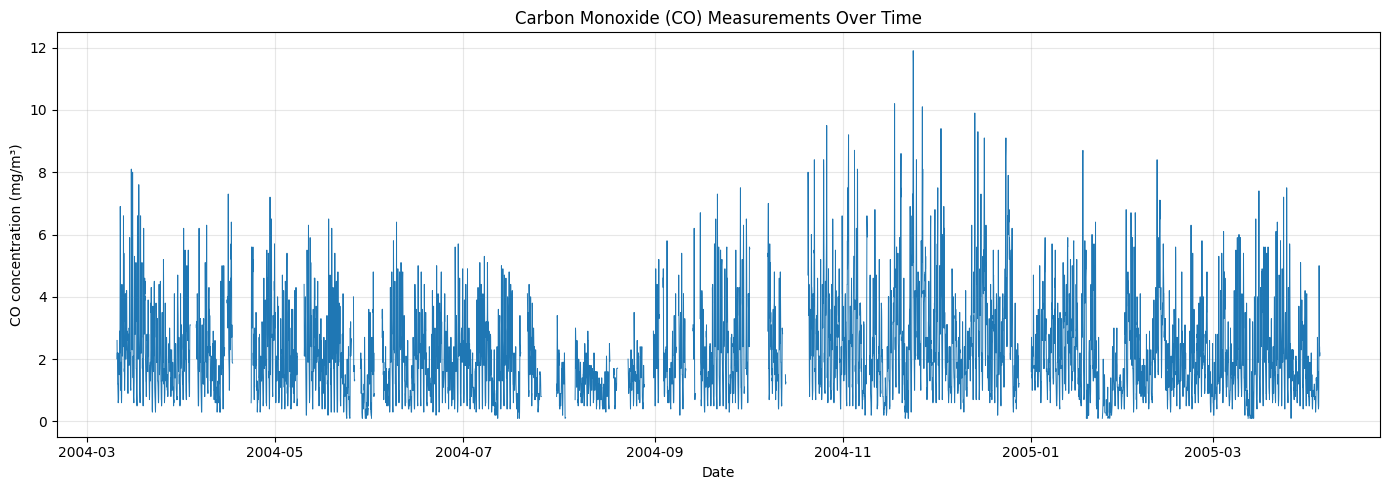

In [5]:

# PART B: EXPLORATORY DATA ANALYSIS

# Fill short gaps for visualization only
# Do not use this filled copy as our final model dataset.
pollutant = "CO(GT)"

plot_df = df[["Datetime", pollutant]].copy()
plot_df[pollutant] = plot_df[pollutant].interpolate(limit=3)

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Datetime"], plot_df[pollutant], linewidth=0.7)
plt.title("Carbon Monoxide (CO) Measurements Over Time")
plt.xlabel("Date")
plt.ylabel("CO concentration (mg/m³)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

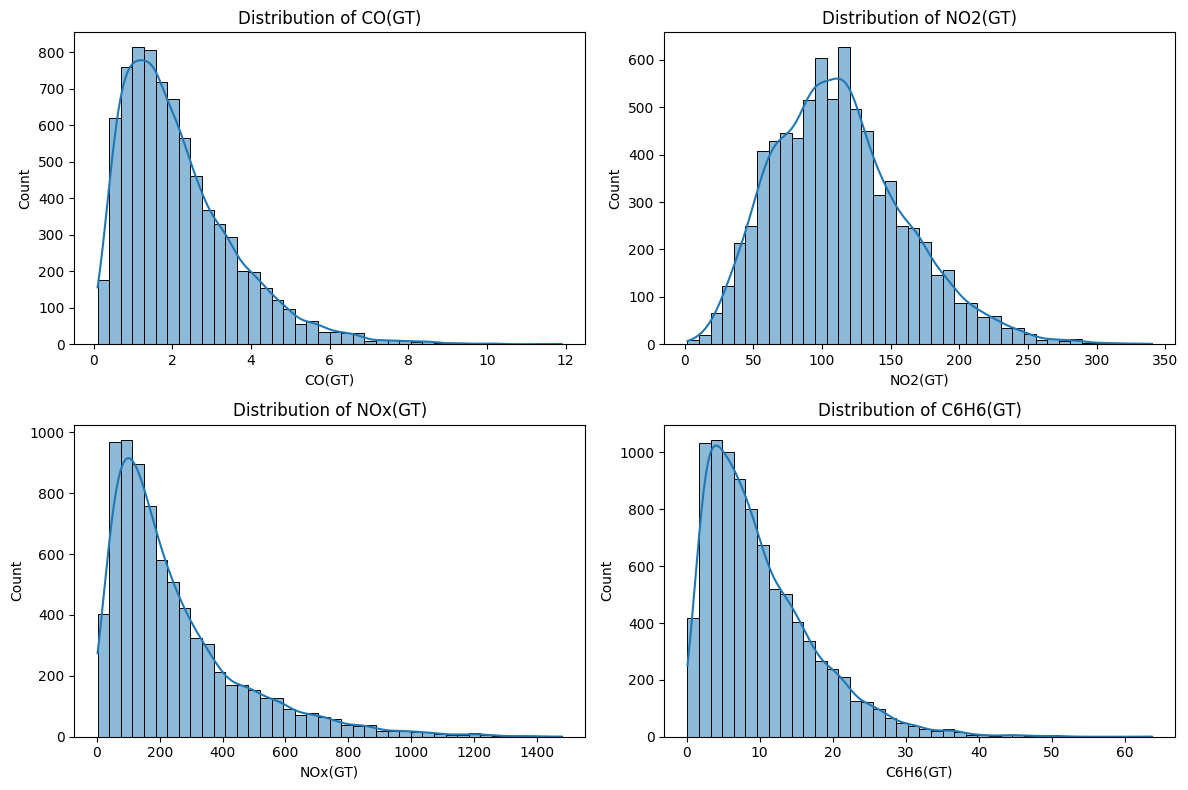

In [6]:

# Distribution of selected air-quality measurements

columns = ["CO(GT)", "NO2(GT)", "NOx(GT)", "C6H6(GT)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, ax in zip(columns, axes.flatten()):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

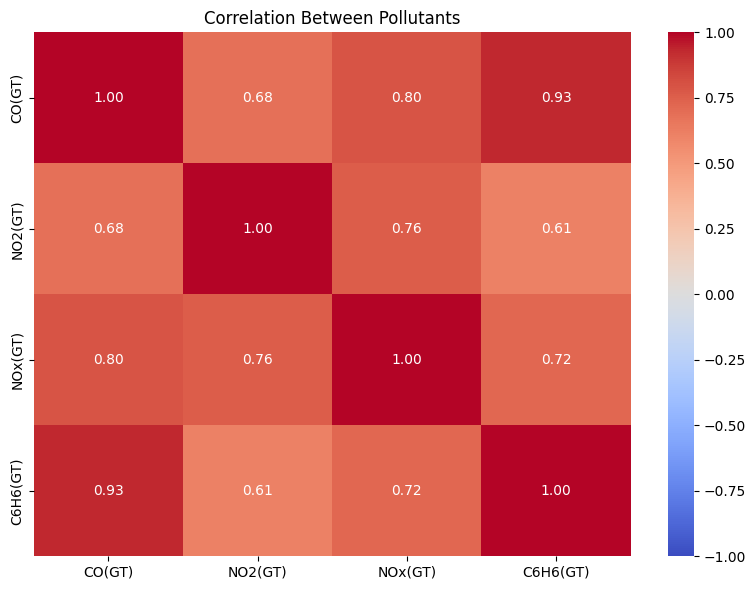

In [7]:

# Correlation between pollutant measurements

pollutants = ["CO(GT)", "NO2(GT)", "NOx(GT)", "C6H6(GT)"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[pollutants].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Correlation Between Pollutants")
plt.tight_layout()
plt.show()

In [8]:

# PART C & D: FEATURE ENGINEERING AND FORECASTING

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Target: CO measurement one hour into the future
data = df[["Datetime", "CO(GT)"]].copy()
data["Target"] = data["CO(GT)"].shift(-1)

# Features available at the current hour
data["CO_lag1"] = data["CO(GT)"]
data["CO_lag2"] = data["CO(GT)"].shift(1)
data["CO_lag3"] = data["CO(GT)"].shift(2)
data["CO_rolling3"] = data["CO(GT)"].shift(1).rolling(3).mean()

data["Hour"] = data["Datetime"].dt.hour
data["DayOfWeek"] = data["Datetime"].dt.dayofweek
data["Month"] = data["Datetime"].dt.month

features = [
    "CO_lag1", "CO_lag2", "CO_lag3", "CO_rolling3",
    "Hour", "DayOfWeek", "Month"
]

# Exclude rows without a future target
data = data.dropna(subset=["Target"]).reset_index(drop=True)

# Split in time order: first 80% train, last 20% test
split = int(len(data) * 0.8)
X_train = data[features].iloc[:split]
X_test = data[features].iloc[split:]
y_train = data["Target"].iloc[:split]
y_test = data["Target"].iloc[split:]

# Impute missing features using training data only
model = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Test results — one-hour-ahead CO forecasting")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Test results — one-hour-ahead CO forecasting
MAE:  0.4084
MSE:  0.3692
RMSE: 0.6076
R²:   0.7958


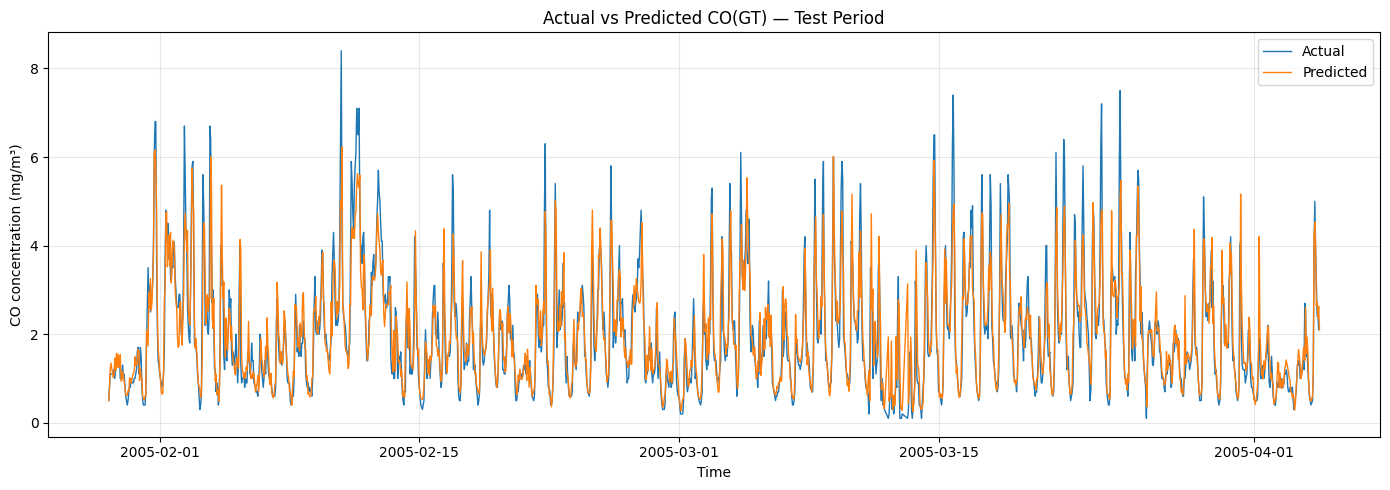

,Importance
CO_lag1,0.717175
Hour,0.113190
CO_lag2,0.048191
Month,0.032794
CO_rolling3,0.031334
CO_lag3,0.029041
DayOfWeek,0.028275


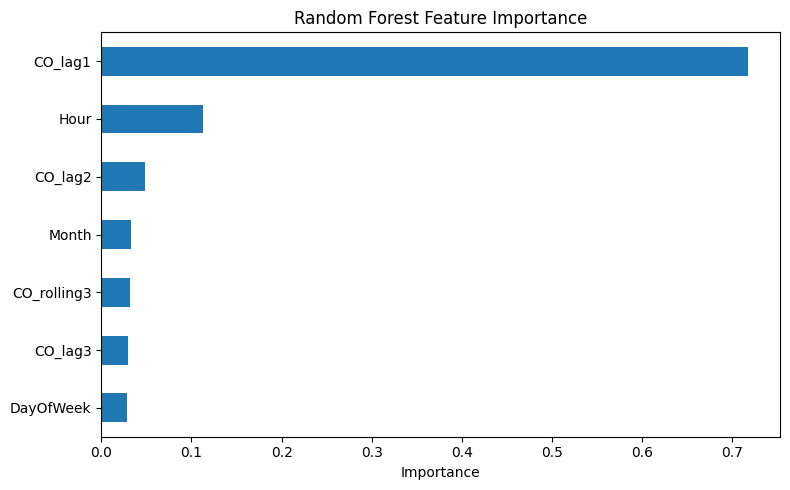

In [9]:

# PART E: PREDICTION ANALYSIS

results = pd.DataFrame({
    "Datetime": data["Datetime"].iloc[split:].values,
    "Actual": y_test.values,
    "Predicted": predictions
})

plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["Actual"], label="Actual", linewidth=1)
plt.plot(results["Datetime"], results["Predicted"], label="Predicted", linewidth=1)
plt.title("Actual vs Predicted CO(GT) — Test Period")
plt.xlabel("Time")
plt.ylabel("CO concentration (mg/m³)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance
importance = pd.Series(
    model.named_steps["randomforestregressor"].feature_importances_,
    index=features
).sort_values(ascending=False)

display(importance.to_frame("Importance"))

importance.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:

# PART G: BASELINE COMPARISON

baseline_predictions = X_test["CO_lag1"].copy()

# Both models are evaluated on the same test rows.
baseline_valid = baseline_predictions.notna()

print("Random Forest MAE:", round(mae, 4))
print(
    "Persistence baseline MAE:",
    round(mean_absolute_error(
        y_test[baseline_valid],
        baseline_predictions[baseline_valid]
    ), 4)
)

Random Forest MAE: 0.4084
Persistence baseline MAE: 0.5148


In [11]:

# SUMMARY FOR YOUR REPORT

print("KEY RESULTS")
print("-----------")
print("Forecast target: CO(GT), one hour ahead")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

print("\nTop 3 features:")
display(importance.head(3))

print("\nLimitations to discuss:")
print("1. Some sensor measurements are missing.")
print("2. The model uses historical measurements, not weather forecasts or traffic data.")
print("3. Performance on this historical dataset may not generalize to other locations.")

KEY RESULTS
-----------
Forecast target: CO(GT), one hour ahead
Training rows: 6138
Testing rows: 1535
MAE: 0.4084
RMSE: 0.6076
R²: 0.7958

Top 3 features:


,0
CO_lag1,0.717175
Hour,0.113190
CO_lag2,0.048191



Limitations to discuss:
1. Some sensor measurements are missing.
2. The model uses historical measurements, not weather forecasts or traffic data.
3. Performance on this historical dataset may not generalize to other locations.
